# Experiment 6: Minima and Maxima for One and Two Variable Functions
**Objective:** To locate critical points of functions of one and two variables using first and second derivatives tests.

In [10]:
# ── CELL 1: Import Libraries ──────────────────────────────────────────────────
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

---
## Part A: Minima / Maxima for ONE Variable Function

In [11]:
# ── CELL 2: Define the One-Variable Function ──────────────────────────────────
x = sp.Symbol('x')

# Example function — change this as needed
f = x**3 - 3*x**2 - 9*x + 5

print("Function: f(x) =", f)

Function: f(x) = x**3 - 3*x**2 - 9*x + 5


In [12]:
# ── CELL 3: First Derivative Test — Find Critical Points ──────────────────────
f1 = sp.diff(f, x)          # First derivative f'(x)
print("First Derivative  f'(x) =", f1)

critical_points = sp.solve(f1, x)
print("Critical Points (where f'(x) = 0):", critical_points)

First Derivative  f'(x) = 3*x**2 - 6*x - 9
Critical Points (where f'(x) = 0): [-1, 3]


In [13]:
# ── CELL 4: Second Derivative Test — Classify Critical Points ─────────────────
f2 = sp.diff(f1, x)         # Second derivative f''(x)
print("Second Derivative f''(x) =", f2)
print()

for pt in critical_points:
    val  = f.subs(x, pt)          # Function value at critical point
    test = f2.subs(x, pt)         # f''(critical point)

    if test > 0:
        kind = "Local MINIMUM"
    elif test < 0:
        kind = "Local MAXIMUM"
    else:
        kind = "Inconclusive (test fails)"

    print(f"  x = {pt}  →  f({pt}) = {val}  →  f''= {test}  →  {kind}")

Second Derivative f''(x) = 6*x - 6

  x = -1  →  f(-1) = 10  →  f''= -12  →  Local MAXIMUM
  x = 3  →  f(3) = -22  →  f''= 12  →  Local MINIMUM


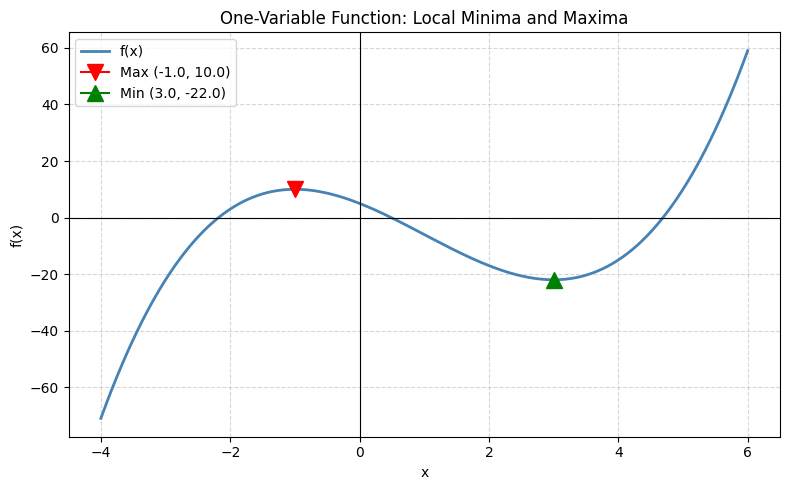

In [14]:
# ── CELL 5: Plot the One-Variable Function with Critical Points ────────────────
x_vals = np.linspace(-4, 6, 400)
f_func = sp.lambdify(x, f, 'numpy')   # Convert sympy expr to numpy function
y_vals = f_func(x_vals)

plt.figure(figsize=(8, 5))
plt.plot(x_vals, y_vals, color='steelblue', linewidth=2, label='f(x)')

# Mark each critical point
for pt in critical_points:
    px = float(pt)
    py = float(f.subs(x, pt))
    test = float(f2.subs(x, pt))
    color  = 'red'   if test < 0 else 'green'
    marker = 'v'     if test < 0 else '^'
    label  = f'Max ({px:.1f}, {py:.1f})' if test < 0 else f'Min ({px:.1f}, {py:.1f})'
    plt.plot(px, py, marker=marker, color=color, markersize=12, label=label)

plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('One-Variable Function: Local Minima and Maxima')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---
## Part B: Minima / Maxima for TWO Variable Function

In [15]:
# ── CELL 6: Define the Two-Variable Function ──────────────────────────────────
x, y = sp.symbols('x y')

# Example function — change this as needed
f2v = x**3 + y**3 - 3*x - 3*y + 5

print("Function: f(x, y) =", f2v)

Function: f(x, y) = x**3 - 3*x + y**3 - 3*y + 5


In [16]:
# ── CELL 7: Partial Derivatives — Find Critical Points ────────────────────────
fx = sp.diff(f2v, x)    # Partial derivative w.r.t x
fy = sp.diff(f2v, y)    # Partial derivative w.r.t y

print("∂f/∂x =", fx)
print("∂f/∂y =", fy)

# Solve the system fx=0, fy=0
critical_pts = sp.solve([fx, fy], [x, y])
print("\nCritical Points:", critical_pts)

∂f/∂x = 3*x**2 - 3
∂f/∂y = 3*y**2 - 3

Critical Points: [(-1, -1), (-1, 1), (1, -1), (1, 1)]


In [17]:
# ── CELL 8: Second Derivative Test using Hessian Determinant ──────────────────
fxx = sp.diff(fx, x)    # ∂²f/∂x²=r
fyy = sp.diff(fy, y)    # ∂²f/∂y²=t
fxy = sp.diff(fx, y)    # ∂²f/∂x∂y=s

print("∂²f/∂x²   =", fxx)
print("∂²f/∂y²   =", fyy)
print("∂²f/∂x∂y  =", fxy)
print()

for pt in critical_pts:
    px, py = pt
    D = (fxx * fyy - fxy**2).subs([(x, px), (y, py)])   # Hessian determinant r*t-s^2
    A = fxx.subs([(x, px), (y, py)])                     # fxx at critical point
    val = f2v.subs([(x, px), (y, py)])

    if D > 0 and A > 0:
        kind = "Local MINIMUM"
    elif D > 0 and A < 0:
        kind = "Local MAXIMUM"
    elif D < 0:
        kind = "SADDLE POINT"
    else:
        kind = "Inconclusive"

    print(f"  Point ({px}, {py})  →  f = {val}  →  D = {D},  fxx = {A}  →  {kind}")

∂²f/∂x²   = 6*x
∂²f/∂y²   = 6*y
∂²f/∂x∂y  = 0

  Point (-1, -1)  →  f = 9  →  D = 36,  fxx = -6  →  Local MAXIMUM
  Point (-1, 1)  →  f = 5  →  D = -36,  fxx = -6  →  SADDLE POINT
  Point (1, -1)  →  f = 5  →  D = -36,  fxx = 6  →  SADDLE POINT
  Point (1, 1)  →  f = 1  →  D = 36,  fxx = 6  →  Local MINIMUM


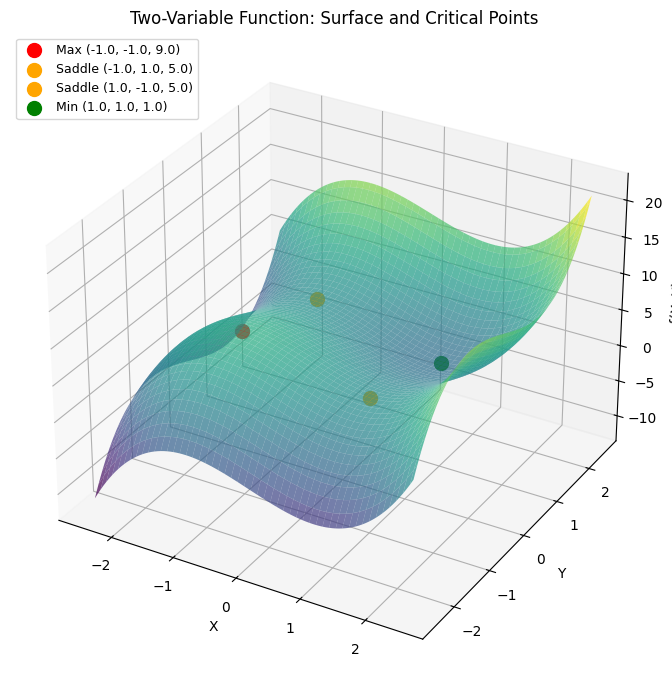

In [18]:
# ── CELL 9: 3D Surface Plot with Critical Points ──────────────────────────────
f2v_func = sp.lambdify((x, y), f2v, 'numpy')

x_range = np.linspace(-2.5, 2.5, 100)
y_range = np.linspace(-2.5, 2.5, 100)
X, Y = np.meshgrid(x_range, y_range)
Z = f2v_func(X, Y)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Surface
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.7, edgecolor='none')

# Mark critical points
for pt in critical_pts:
    px, py = float(pt[0]), float(pt[1])
    pz = float(f2v.subs([(x, pt[0]), (y, pt[1])]))
    D  = float((fxx * fyy - fxy**2).subs([(x, pt[0]), (y, pt[1])]))
    A  = float(fxx.subs([(x, pt[0]), (y, pt[1])]))

    if D > 0 and A > 0:
        color, label = 'green', 'Min'
    elif D > 0 and A < 0:
        color, label = 'red', 'Max'
    else:
        color, label = 'orange', 'Saddle'

    ax.scatter(px, py, pz, color=color, s=100, zorder=5,
               label=f'{label} ({px:.1f}, {py:.1f}, {pz:.1f})')

ax.set_title('Two-Variable Function: Surface and Critical Points')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('f(X, Y)')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

##Lab experiment
For one Variable

1.   $$f(x) = x^3 - 6x^2 + 9x + 2$$
2.   $$f(x) = x^4 - 4x^3 + 4x^2$$
##   For Two variable
3.    $$f(x, y) = 3x^2 + 3y^2 - 6x - 12y + 20$$
4.    $$f(x, y) = x^2 - y^2 + 4x - 2y + 1$$


